# 🛫 Prévision des Retards Aériens — Notebook MLflow
**Projet PPML- FlyOnTime — 6 plus grands aéroports français**


### Configuration & Imports

In [1]:
import pandas as pd
import os
import numpy as np
import shap
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from pandas.api.types import is_datetime64_any_dtype
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import mlflow

### Connexion MLflow

In [ ]:
# --- 1. CONFIGURATION SERVEUR ---
MLFLOW_REMOTE_URI = "https://ppml2026-ppml-mlflow.hf.space"
mlflow.set_tracking_uri(MLFLOW_REMOTE_URI)

PRENOM = "Ludo"
TYPE_MODEL = "XGBoost"

EXPERIMENT_NAME = f"FlyOnTime_classif"
RUN_NAME        = f"{TYPE_MODEL}_classifier"
MODEL_NAME_TAG  = f"{TYPE_MODEL}_classifier_{PRENOM}"
REGISTERED_NAME = "FlyOnTime_classif"
ALIAS_NAME      = "challenger"

while mlflow.active_run():
    mlflow.end_run()
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"✅ Connecté à : {MLFLOW_REMOTE_URI}")
print(f"🚀 Run : {RUN_NAME} | Tag : {MODEL_NAME_TAG}")

✅ Connecté à : https://stoneray-ppml-mlflow.hf.space/
🚀 Run : XGBoost_classifier | Tag : XGBoost_classifier_Ludo


### Chargement des données

**Source :** AWS S3 (format Parquet)

**Datasets :**
- `df_train` → données historiques pour l'entraînement
- `df_predict` → données d'avril 2026 pour la prédiction finale

In [3]:
import boto3

# Fonction pour récupérer mes fichiers sur le bucket S3 de l'équipe
def charger_data_s3(chemin_fichier):
    # Setup de la session avec mes accès
    session = boto3.Session(
        aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID_EQUIPE"),
        aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY_EQUIPE"),
        region_name="eu-north-1"
    )
    
    nom_bucket = os.getenv("BUCKET_EQUIPE")
    url_complete = f"s3://{nom_bucket}/{chemin_fichier}"
    
    print(f"Récupération du fichier : {chemin_fichier}...")
    
    
    if chemin_fichier.endswith('.csv'):
        return pd.read_csv(url_complete)
    else:
        return pd.read_parquet(url_complete)

# Chargement depuis S3
df_train = charger_data_s3("datasets/SignofFlightsDataset_20260416_233018_CLEAN.csv")
df_predict = charger_data_s3("datasets/SignofFlightsDataset_future_20260416_233150_CLEAN.csv")

# Je vérifie le format
print(f"Format Train   : {df_train.shape}")
print(f"Format Predict : {df_predict.shape}")

Récupération du fichier : datasets/SignofFlightsDataset_20260416_233018_CLEAN.csv...


C:\Users\surel\AppData\Local\Temp\ipykernel_3596\744087605.py:19: DtypeWarning: Columns (64,65,67,76,80,82,84,86) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(url_complete)


Récupération du fichier : datasets/SignofFlightsDataset_future_20260416_233150_CLEAN.csv...
Format Train   : (94378, 96)
Format Predict : (4063, 96)


In [4]:
df_train.to_csv("df_train.csv", index=False)

In [6]:
# Aperçu rapide des colonnes disponibles
print("Colonnes df_train :")
print(df_train.columns.tolist())
print("Colonnes df_predict :")
print(df_predict.columns.tolist())
print("---------------------------")
print("Aperçu df_train :")
df_train.head()


Colonnes df_train :
['flight_date', 'movement_date', 'flight_number', 'airline', 'airport_origin', 'airport_destination', 'terminal_departure', 'terminal_arrival', 'scheduled_departure', 'scheduled_arrival', 'estimated_departure', 'estimated_arrival', 'actual_departure', 'actual_arrival', 'actual_source_departure', 'actual_source_arrival', 'departure_delay_min', 'departure_advance_min', 'arrival_delay_min', 'arrival_advance_min', 'status', 'movement_type', 'time_dep', 'relative_humidity_2m_dep', 'dew_point_dep', 'icing_conditions_dep', 'rain_dep', 'freezing_rain_dep', 'snow_dep', 'thunderstorms_dep', 'pressure_msl_dep', 'wind_shear_dep', 'wind_gusts_10m_dep', 'wind_speed_10m_dep', 'wind_direction_10m_dep', 'precipitation_dep', 'has_precipitation_dep', 'fog_dep', 'humidity_dep', 'temperature_2m_dep', 'cloud_cover_dep', 'cloud_base_dep', 'visibility_dep', 'time_arr', 'relative_humidity_2m_arr', 'dew_point_arr', 'icing_conditions_arr', 'rain_arr', 'freezing_rain_arr', 'snow_arr', 'thunder

,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,...,LABEL_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée
0,DATE_GENERATION,2026-04-17 03:31:48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-09-21,2025-09-21,AF 1249,Air France,MRS,CDG,NaN,2F,NaN,2025-09-21 23:10+02:00,...,NaN,137.0,131.0,268.0,1.0,680.0,654.0,1334.0,0.0,1.0
2,2025-09-21,2025-09-21,AF 6004,Air France,ORY,MRS,3,1,2025-09-21 09:15+02:00,2025-09-21 10:35+02:00,...,NaN,350.0,346.0,696.0,0.0,137.0,131.0,268.0,1.0,0.0
3,2025-09-21,2025-09-21,AF 6009,Air France,MRS,ORY,1,NaN,2025-09-21 16:20+02:00,NaN,...,NaN,137.0,131.0,268.0,1.0,350.0,346.0,696.0,0.0,1.0
4,2025-09-21,2025-09-21,AF 6104,Air France,ORY,TLS,3,NaN,2025-09-21 08:00+02:00,2025-09-21 09:15+02:00,...,NaN,350.0,346.0,696.0,0.0,79.0,82.0,161.0,0.0,0.0


### On voit que la première ligne est inutile

In [7]:
print(df_train.iloc[0])
df_train = df_train.iloc[1:].reset_index(drop=True)
df_predict = df_predict.iloc[1:].reset_index(drop=True)


display(df_train.head())
print("-----------------------------------------------------------------------")
display(df_predict.head())

flight_date                             DATE_GENERATION
movement_date                       2026-04-17 03:31:48
flight_number                                       NaN
airline                                             NaN
airport_origin                                      NaN
                                           ...         
nombre_departs_destination                          NaN
nombre_arrivees_destination                         NaN
somme_depart_arrivee_destination                    NaN
congestion_destination                              NaN
retard arrivée                                      NaN
Name: 0, Length: 96, dtype: object


,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,...,LABEL_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée
0,2025-09-21,2025-09-21,AF 1249,Air France,MRS,CDG,NaN,2F,NaN,2025-09-21 23:10+02:00,...,NaN,137.0,131.0,268.0,1.0,680.0,654.0,1334.0,0.0,1.0
1,2025-09-21,2025-09-21,AF 6004,Air France,ORY,MRS,3,1,2025-09-21 09:15+02:00,2025-09-21 10:35+02:00,...,NaN,350.0,346.0,696.0,0.0,137.0,131.0,268.0,1.0,0.0
2,2025-09-21,2025-09-21,AF 6009,Air France,MRS,ORY,1,NaN,2025-09-21 16:20+02:00,NaN,...,NaN,137.0,131.0,268.0,1.0,350.0,346.0,696.0,0.0,1.0
3,2025-09-21,2025-09-21,AF 6104,Air France,ORY,TLS,3,NaN,2025-09-21 08:00+02:00,2025-09-21 09:15+02:00,...,NaN,350.0,346.0,696.0,0.0,79.0,82.0,161.0,0.0,0.0
4,2025-09-21,2025-09-21,AF 6108,Air France,ORY,TLS,3,NaN,2025-09-21 12:00+02:00,2025-09-21 13:15+02:00,...,NaN,350.0,346.0,696.0,0.0,79.0,82.0,161.0,0.0,0.0


-----------------------------------------------------------------------


,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,...,LABEL_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée
0,2026-04-17,2026-04-17,AF 6212,Air France,ORY,NCE,2,2,2026-04-17 12:35+02:00,2026-04-17 14:05+02:00,...,NaN,550.0,540.0,1090.0,1.0,179.0,177.0,356.0,0.0,0.0
1,2026-04-17,2026-04-17,AF 7300,Air France,CDG,NCE,2F,2,2026-04-17 06:45+02:00,2026-04-17 08:15+02:00,...,NaN,NaN,NaN,NaN,0.0,179.0,177.0,356.0,0.0,0.0
2,2026-04-17,2026-04-17,AF 7301,Air France,NCE,CDG,2,2F,2026-04-17 09:05+02:00,2026-04-17 10:40+02:00,...,NaN,179.0,177.0,356.0,0.0,NaN,NaN,NaN,0.0,0.0
3,2026-04-17,2026-04-17,AF 7302,Air France,CDG,NCE,2F,2,2026-04-17 07:15+02:00,2026-04-17 08:50+02:00,...,NaN,NaN,NaN,NaN,0.0,179.0,177.0,356.0,0.0,0.0
4,2026-04-17,2026-04-17,AF 7303,Air France,NCE,CDG,2,2F,2026-04-17 09:45+02:00,2026-04-17 11:20+02:00,...,NaN,179.0,177.0,356.0,0.0,NaN,NaN,NaN,0.0,0.0


### --- Vérification des doublons ---
Normalement, un numéro de vol sur une même journée, c'est unique. 
Si j'en ai plusieurs, c'est qu'il y a un bug dans l'extraction.

In [8]:
# --- VÉRIFICATION DES DOUBLONS (Train & Predict) ---

# 1. Check sur les données d'entraînement
doublons_train = df_train[df_train.duplicated(subset=["flight_number", "flight_date"], keep=False)]
print(f"⚠️ Doublons dans le Train : {len(doublons_train)}")

# 2. Check sur les données futures (histoire d'être sûr)
doublons_predict = df_predict[df_predict.duplicated(subset=["flight_number", "flight_date"], keep=False)]
print(f"🔍 Doublons dans le Predict : {len(doublons_predict)}")

# Si j'ai un doute sur le futur, je regarde
if len(doublons_predict) > 0:
    print("Aperçu des doublons 'Futur' :")
    display(doublons_predict.sort_values(by=["flight_number", "flight_date"]).head(6))

⚠️ Doublons dans le Train : 1572
🔍 Doublons dans le Predict : 92
Aperçu des doublons 'Futur' :


,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,...,LABEL_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée
162,2026-04-17,2026-04-17,AR 7826,Aerolineas Argentinas,CDG,LYS,2F,1,2026-04-17 12:35+02:00,2026-04-17 13:45+02:00,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,0.0
163,2026-04-17,2026-04-17,AR 7826,Aerolineas Argentinas,CDG,LYS,2F,1,2026-04-17 17:00+02:00,2026-04-17 18:10+02:00,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,0.0
1360,2026-04-19,2026-04-19,AR 7826,Aerolineas Argentinas,CDG,LYS,2F,1,2026-04-19 12:35+02:00,2026-04-19 13:45+02:00,...,NaN,2245.0,2256.0,4501.0,0.0,239.0,243.0,482.0,1.0,0.0
1361,2026-04-19,2026-04-19,AR 7826,Aerolineas Argentinas,CDG,LYS,2F,1,2026-04-19 16:40+02:00,2026-04-19 17:50+02:00,...,NaN,2245.0,2256.0,4501.0,0.0,239.0,243.0,482.0,1.0,0.0
1924,2026-04-20,2026-04-20,AR 7826,Aerolineas Argentinas,CDG,LYS,2F,1,2026-04-20 12:35+02:00,2026-04-20 13:45+02:00,...,NaN,2241.0,2257.0,4498.0,0.0,246.0,253.0,499.0,1.0,0.0
1925,2026-04-20,2026-04-20,AR 7826,Aerolineas Argentinas,CDG,LYS,2F,1,2026-04-20 17:00+02:00,2026-04-20 18:10+02:00,...,NaN,2241.0,2257.0,4498.0,0.0,246.0,253.0,499.0,1.0,0.0


Nous avons identifié que les doublons apparents ne correspondent pas à des escales, mais à deux lignes complémentaires décrivant un même vol : l’une pour le départ et l’autre pour l’arrivée. Il ne faut donc pas supprimer ces lignes ni les traiter séparément, car cela entraînerait une perte d’information et un biais dans le modèle. La bonne approche consiste à regrouper ces lignes pour reconstruire un vol complet en une seule observation, en combinant les informations de départ et d’arrivée (par exemple via un groupby et des agrégations adaptées).

In [ ]:
# # --- ANALYSE DES DOUBLONS (TRAIN & PREDICT) ---

# # Définition des colonnes qui identifient un vol unique
# cles_doublons = ["flight_number", "flight_date", "airport_origin", "airport_destination"]

# # 1. Analyse pour le TRAIN
# masque_train = df_train.duplicated(subset=cles_doublons, keep=False)
# vols_doubles_train = df_train[masque_train]
# vols_uniques_train = df_train[~masque_train]

# # 2. Analyse pour le PREDICT
# masque_predict = df_predict.duplicated(subset=cles_doublons, keep=False)
# vols_doubles_predict = df_predict[masque_predict]
# vols_uniques_predict = df_predict[~masque_predict]

# # --- VÉRIFICATION DES THÉORIES ---
# print(f"📊 TRAIN   : {len(vols_doubles_train)} lignes en doublons ({len(vols_doubles_train)//2} vols)")
# print(vols_doubles_train["movement_type"].value_counts())

# print(f"\n📊 PREDICT : {len(vols_doubles_predict)} lignes en doublons ({len(vols_doubles_predict)//2} vols)")
# print(vols_doubles_predict["movement_type"].value_counts())

# Si les volumes Departure/Arrival sont quasi identiques, on confirme la structure "vols coupés en deux"

In [9]:
display(df_train[df_train.duplicated(subset=["flight_number", "flight_date", "airport_origin", "airport_destination"], keep=False)])
display(df_predict[df_predict.duplicated(subset=["flight_number", "flight_date", "airport_origin", "airport_destination"], keep=False)])


,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,...,LABEL_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée
955,2025-09-25,2025-09-25,WT 5748,Swiftair,MRS,CDG,NaN,NaN,2025-09-25 22:45+02:00,NaN,...,NaN,148.0,149.0,297.0,1.0,690.0,658.0,1348.0,0.0,0.0
956,2025-09-25,2025-09-25,WT 5748,Swiftair,MRS,CDG,NaN,NaN,NaN,2025-09-25 00:59+02:00,...,NaN,148.0,149.0,297.0,1.0,690.0,658.0,1348.0,0.0,0.0
994,2025-09-26,2025-09-26,AF 6224,Air France,ORY,NCE,3,NaN,2025-09-26 18:35+02:00,NaN,...,NaN,356.0,350.0,706.0,0.0,199.0,198.0,397.0,1.0,1.0
995,2025-09-26,2025-09-26,AF 6224,Air France,ORY,NCE,NaN,2,NaN,2025-09-26 20:00+02:00,...,NaN,356.0,350.0,706.0,0.0,199.0,198.0,397.0,1.0,0.0
1669,2025-10-02,2025-10-02,AF 7365,Air France,LYS,CDG,1,NaN,2025-10-02 11:35+02:00,NaN,...,NaN,233.0,237.0,470.0,1.0,646.0,636.0,1282.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94096,2026-04-17,2026-04-17,KE 6446,Korean Air,LYS,CDG,1,2F,2026-04-17 19:00+02:00,2026-04-17 20:10+02:00,...,NaN,236.0,236.0,472.0,1.0,2525.0,2519.0,5044.0,1.0,0.0
94159,2026-04-17,2026-04-17,MU 1512,China Eastern,LYS,CDG,1,2F,2026-04-17 06:00+02:00,2026-04-17 07:20+02:00,...,NaN,236.0,236.0,472.0,1.0,2525.0,2519.0,5044.0,1.0,0.0
94160,2026-04-17,2026-04-17,MU 1512,China Eastern,LYS,CDG,1,2F,2026-04-17 14:40+02:00,2026-04-17 15:50+02:00,...,NaN,236.0,236.0,472.0,1.0,2525.0,2519.0,5044.0,1.0,0.0
94168,2026-04-17,2026-04-17,MU 1531,China Eastern,CDG,MRS,2F,1,2026-04-17 09:45+02:00,2026-04-17 11:15+02:00,...,NaN,2525.0,2519.0,5044.0,1.0,137.0,139.0,276.0,1.0,0.0


,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,...,LABEL_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée
162,2026-04-17,2026-04-17,AR 7826,Aerolineas Argentinas,CDG,LYS,2F,1,2026-04-17 12:35+02:00,2026-04-17 13:45+02:00,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,0.0
163,2026-04-17,2026-04-17,AR 7826,Aerolineas Argentinas,CDG,LYS,2F,1,2026-04-17 17:00+02:00,2026-04-17 18:10+02:00,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,0.0
251,2026-04-17,2026-04-17,DL 8568,Delta Air Lines,CDG,LYS,2F,1,2026-04-17 08:25+02:00,2026-04-17 09:30+02:00,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,0.0
252,2026-04-17,2026-04-17,DL 8568,Delta Air Lines,CDG,LYS,2F,1,2026-04-17 12:35+02:00,2026-04-17 13:45+02:00,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,0.0
383,2026-04-17,2026-04-17,KE 6446,Korean Air,LYS,CDG,1,2F,2026-04-17 14:40+02:00,2026-04-17 15:50+02:00,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3857,2026-04-23,2026-04-23,MU 1512,China Eastern,LYS,CDG,1,2F,2026-04-23 14:40+02:00,2026-04-23 15:50+02:00,...,NaN,233.0,242.0,475.0,1.0,2192.0,2211.0,4403.0,0.0,0.0
3865,2026-04-23,2026-04-23,MU 1531,China Eastern,CDG,MRS,2F,1,2026-04-23 09:45+02:00,2026-04-23 11:15+02:00,...,NaN,2192.0,2211.0,4403.0,0.0,142.0,146.0,288.0,0.0,0.0
3866,2026-04-23,2026-04-23,MU 1531,China Eastern,CDG,MRS,2F,1,2026-04-23 21:25+02:00,2026-04-23 22:50+02:00,...,NaN,2192.0,2211.0,4403.0,0.0,142.0,146.0,288.0,0.0,0.0
3875,2026-04-23,2026-04-23,MU 1768,China Eastern,LYS,CDG,1,NaN,2026-04-23 10:20+02:00,NaN,...,NaN,233.0,242.0,475.0,1.0,2192.0,2211.0,4403.0,0.0,0.0


Il arrive que certain avions fassent plusieurs rotations par jour 
Quand on "recolle" le vol, on crée une seule ligne ultra-complète.
Avant (2 lignes) :
Ligne 1 : Vol AF1234 | Départ Paris | Vent 20km/h
Ligne 2 : Vol AF1234 | Arrivée Nice | Pluie | Retard 15min
Après (1 vol recollé) : Ligne Unique : Vol AF1234 | Départ Paris (Vent 20km/h) | Arrivée Nice (Pluie) | Retard 15min

In [10]:
df_train_final = df_train.drop_duplicates(subset=["flight_number", "flight_date", "airport_origin", "airport_destination"], keep=False)
df_predict_final = df_predict.drop_duplicates(subset=["flight_number", "flight_date", "airport_origin", "airport_destination"], keep=False)
# --- BILAN ---
print(f"✅ TRAIN   : {len(df_train_final)} vols prêts.")
print(f"✅ PREDICT : {len(df_predict_final)} vols prêts.")

✅ TRAIN   : 92897 vols prêts.
✅ PREDICT : 3982 vols prêts.


In [11]:
df_train_final.head()

,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,...,LABEL_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée
0,2025-09-21,2025-09-21,AF 1249,Air France,MRS,CDG,NaN,2F,NaN,2025-09-21 23:10+02:00,...,NaN,137.0,131.0,268.0,1.0,680.0,654.0,1334.0,0.0,1.0
1,2025-09-21,2025-09-21,AF 6004,Air France,ORY,MRS,3,1,2025-09-21 09:15+02:00,2025-09-21 10:35+02:00,...,NaN,350.0,346.0,696.0,0.0,137.0,131.0,268.0,1.0,0.0
2,2025-09-21,2025-09-21,AF 6009,Air France,MRS,ORY,1,NaN,2025-09-21 16:20+02:00,NaN,...,NaN,137.0,131.0,268.0,1.0,350.0,346.0,696.0,0.0,1.0
3,2025-09-21,2025-09-21,AF 6104,Air France,ORY,TLS,3,NaN,2025-09-21 08:00+02:00,2025-09-21 09:15+02:00,...,NaN,350.0,346.0,696.0,0.0,79.0,82.0,161.0,0.0,0.0
4,2025-09-21,2025-09-21,AF 6108,Air France,ORY,TLS,3,NaN,2025-09-21 12:00+02:00,2025-09-21 13:15+02:00,...,NaN,350.0,346.0,696.0,0.0,79.0,82.0,161.0,0.0,0.0


### --- BILAN DE SANTÉ FINAL ---
 Je rajoute l'heure de départ prévue ('scheduled_departure') dans le filtre pour prendre en compte l'heure de départ.

In [12]:
colonnes_cles = ['flight_number', 'flight_date', 'scheduled_departure']
 
nb_train = df_train_final.duplicated(subset=colonnes_cles).sum()
nb_predict = df_predict_final.duplicated(subset=colonnes_cles).sum()
print(f"Bilan de santé Train   : {nb_train} vrais doublons.")
print(f"Bilan de santé Predict : {nb_predict} vrais doublons.")
if nb_train + nb_predict == 0:
    print("\n✅ Nickel ! Tout est propre, chaque vol est désormais une ligne unique.")
else:
    print("\n⚠️ Attention, il reste encore des rescapés à checker.")

Bilan de santé Train   : 0 vrais doublons.
Bilan de santé Predict : 0 vrais doublons.

✅ Nickel ! Tout est propre, chaque vol est désormais une ligne unique.


In [ ]:
#%who DataFrame
#on travaille désormais sur df_train_final et df_predict_final, qui sont nos datasets réparés et prêts pour l'analyse et le modeling.

### On s'occupe des NaN 🫓

In [13]:
print(f" Dimensions du TRAIN   : {df_train_final.shape} (Lignes, Colonnes)")
print(f" Dimensions du PREDICT : {df_predict_final.shape} (Lignes, Colonnes)")

📏 Dimensions du TRAIN   : (92897, 96) (Lignes, Colonnes)
📏 Dimensions du PREDICT : (3982, 96) (Lignes, Colonnes)


In [14]:
def check_missing(df, name):
    print(f"\n ANALYSE : {name}")
    stats = (df.isna().mean() * 100).sort_values(ascending=False)
    stats_filtered = stats[stats > 0]
    if not stats_filtered.empty:
        print(stats_filtered.head(30))
    else:
        print(" Propre comme un sou neuf !")

check_missing(df_train_final, "TRAIN")
check_missing(df_predict_final, "PREDICT")


🔍 ANALYSE : TRAIN
visibility_arr              100.000000
cloud_base_arr              100.000000
cloud_base_dep              100.000000
LABEL_TOULOUSE              100.000000
visibility_dep              100.000000
LABEL_CDG                    99.443470
LABEL_ORLY                   99.374576
Label Jour Ferié             99.146366
LABEL_MARSEILLE              96.425073
LABEL_LYON                   96.008483
LABEL_NICE                   93.962130
Vacances Scolaires           63.202256
Label des Vacances           63.202256
actual_arrival               33.343380
arrival_advance_min          33.343380
actual_source_arrival        33.343380
departure_delay_min          25.008343
departure_advance_min        25.008343
actual_source_departure      25.008343
actual_departure             25.008343
terminal_departure           15.480586
terminal_arrival             14.642023
arrival_delay_min             3.208930
dew_point_arr                 1.543645
time_arr                      1.543645
relati

In [15]:
def purger_et_voir(df, nom_dataset):
    print(f"\n---  NETTOYAGE : {nom_dataset} ---")
    colonnes_avant = set(df.columns)
    cles = ["flight_number", "flight_date", "airport_origin", "airport_destination"]
    # On protège tout ce qui contient "delay" ou "retard"
    mots_cles_proteges = ['delay', 'retard', 'target'] 
    
    cols_a_garder = [c for c in df.columns if 
                     c.endswith(('_dep', '_arr')) or 
                     c in cles or 
                     any(mot in c.lower() for mot in mots_cles_proteges)]
    
    df_filtre = df[cols_a_garder].copy()
    
    seuil = 0.6 
    taux_nan = df_filtre.isnull().mean()
    cols_trop_vides = [c for c in taux_nan[taux_nan > seuil].index 
                       if not any(mot in c.lower() for mot in mots_cles_proteges)]
    
    df_final = df_filtre.drop(columns=cols_trop_vides)
    
    fantômes = colonnes_avant - set(cols_a_garder)
    print(f" {len(fantômes)} colonnes sans suffixe supprimées.")
    print(f" {len(cols_trop_vides)} colonnes > {seuil*100}% vides supprimées.")
    print(f" Colonnes de retard préservées : {[c for c in df_final.columns if any(mot in c.lower() for mot in mots_cles_proteges)]}")
    
    return df_final.ffill().bfill()

# On relance
df_train_final = purger_et_voir(df_train_final, "TRAIN")
df_predict_final = purger_et_voir(df_predict_final, "PREDICT")


---  NETTOYAGE : TRAIN ---
 47 colonnes sans suffixe supprimées.
 4 colonnes > 60.0% vides supprimées.
 Colonnes de retard préservées : ['departure_delay_min', 'arrival_delay_min', 'retard arrivée']

---  NETTOYAGE : PREDICT ---
 47 colonnes sans suffixe supprimées.
 4 colonnes > 60.0% vides supprimées.
 Colonnes de retard préservées : ['departure_delay_min', 'arrival_delay_min', 'retard arrivée']


In [16]:
def scan_total_vides(df, name):
    print(f"\n SCAN COMPLET : {name}")
    nans = df.isna().sum().sum()
    
    vides = (df == "").sum().sum()
    placeholders = ["none", "null", "unknown", "missing", "nan", "undefined"]
    text_vides = df.apply(lambda x: x.astype(str).str.lower().isin(placeholders)).sum().sum()
    infinites = np.isinf(df.select_dtypes(include=np.number)).sum().sum()

    print(f"  - NaNs classiques      : {nans}")
    print(f"  - Textes vides ('' )   : {vides}")
    print(f"  - Mots-clés 'vides'    : {text_vides}")
    print(f"  - Valeurs infinies     : {infinites}")

scan_total_vides(df_train_final, "TRAIN")
scan_total_vides(df_predict_final, "PREDICT")


 SCAN COMPLET : TRAIN
  - NaNs classiques      : 0
  - Textes vides ('' )   : 0
  - Mots-clés 'vides'    : 0
  - Valeurs infinies     : 0

 SCAN COMPLET : PREDICT
  - NaNs classiques      : 7964
  - Textes vides ('' )   : 0
  - Mots-clés 'vides'    : 7964
  - Valeurs infinies     : 0


In [17]:
print("Columnes Train:", list(df_train_final.columns))
print("\nColumnes Predict:", list(df_predict_final.columns))
 
diff = set(df_train_final.columns) ^ set(df_predict_final.columns)
print(f"\n✅ Identiques : {not diff}" if not diff else f"⚠️ Différences : {diff}")

Columnes Train: ['flight_date', 'flight_number', 'airport_origin', 'airport_destination', 'departure_delay_min', 'arrival_delay_min', 'time_dep', 'relative_humidity_2m_dep', 'dew_point_dep', 'icing_conditions_dep', 'rain_dep', 'freezing_rain_dep', 'snow_dep', 'thunderstorms_dep', 'pressure_msl_dep', 'wind_shear_dep', 'wind_gusts_10m_dep', 'wind_speed_10m_dep', 'wind_direction_10m_dep', 'precipitation_dep', 'has_precipitation_dep', 'fog_dep', 'humidity_dep', 'temperature_2m_dep', 'cloud_cover_dep', 'time_arr', 'relative_humidity_2m_arr', 'dew_point_arr', 'icing_conditions_arr', 'rain_arr', 'freezing_rain_arr', 'snow_arr', 'thunderstorms_arr', 'pressure_msl_arr', 'wind_shear_arr', 'wind_gusts_10m_arr', 'wind_speed_10m_arr', 'wind_direction_10m_arr', 'precipitation_arr', 'has_precipitation_arr', 'fog_arr', 'humidity_arr', 'temperature_2m_arr', 'cloud_cover_arr', 'retard arrivée']

Columnes Predict: ['flight_date', 'flight_number', 'airport_origin', 'airport_destination', 'departure_delay_

In [18]:
df_train_final.head()

,flight_date,flight_number,airport_origin,airport_destination,departure_delay_min,arrival_delay_min,time_dep,relative_humidity_2m_dep,dew_point_dep,icing_conditions_dep,...,wind_gusts_10m_arr,wind_speed_10m_arr,wind_direction_10m_arr,precipitation_arr,has_precipitation_arr,fog_arr,humidity_arr,temperature_2m_arr,cloud_cover_arr,retard arrivée
0,2025-09-21,AF 1249,MRS,CDG,9.0,50.0,2025-09-21 07:00:00+00:00,84.0,11.4,Non,...,28.1,14.5,32.0,0.0,Non,Non,85.0,11.6,4.0,1.0
1,2025-09-21,AF 6004,ORY,MRS,9.0,9.0,2025-09-21 07:00:00+00:00,84.0,11.4,Non,...,22.3,7.6,121.0,0.2,Oui,Non,62.0,22.9,100.0,0.0
2,2025-09-21,AF 6009,MRS,ORY,109.0,109.0,2025-09-21 14:00:00+00:00,87.0,18.2,Non,...,22.3,7.6,121.0,0.2,Oui,Non,62.0,22.9,100.0,1.0
3,2025-09-21,AF 6104,ORY,TLS,13.0,0.0,2025-09-21 06:00:00+00:00,84.0,11.4,Non,...,23.0,9.1,321.0,0.0,Non,Non,86.0,16.4,100.0,0.0
4,2025-09-21,AF 6108,ORY,TLS,11.0,11.0,2025-09-21 10:00:00+00:00,74.0,10.6,Non,...,25.9,10.6,320.0,0.1,Oui,Non,79.0,16.7,100.0,0.0


### On définit la notion de retard

In [19]:
df_train_final["retard_arrivee"] = (df_train_final["arrival_delay_min"] > 15).astype(int)
if "arrival_delay_min" in df_train_final.columns:
    df_train_final["retard_arrivee"] = (df_train_final["arrival_delay_min"] > 15).astype(int)

print("Colonne 'retard_arrivee' créée avec succès !")
print(f"Répartition dans le Train :\n{df_train_final['retard_arrivee'].value_counts()}")

Colonne 'retard_arrivee' créée avec succès !
Répartition dans le Train :
retard_arrivee
0    63393
1    29504
Name: count, dtype: int64


In [20]:
df_train_final.drop(columns=['retard arrivée'], inplace=True)


In [21]:
df_train_final.head()

,flight_date,flight_number,airport_origin,airport_destination,departure_delay_min,arrival_delay_min,time_dep,relative_humidity_2m_dep,dew_point_dep,icing_conditions_dep,...,wind_gusts_10m_arr,wind_speed_10m_arr,wind_direction_10m_arr,precipitation_arr,has_precipitation_arr,fog_arr,humidity_arr,temperature_2m_arr,cloud_cover_arr,retard_arrivee
0,2025-09-21,AF 1249,MRS,CDG,9.0,50.0,2025-09-21 07:00:00+00:00,84.0,11.4,Non,...,28.1,14.5,32.0,0.0,Non,Non,85.0,11.6,4.0,1
1,2025-09-21,AF 6004,ORY,MRS,9.0,9.0,2025-09-21 07:00:00+00:00,84.0,11.4,Non,...,22.3,7.6,121.0,0.2,Oui,Non,62.0,22.9,100.0,0
2,2025-09-21,AF 6009,MRS,ORY,109.0,109.0,2025-09-21 14:00:00+00:00,87.0,18.2,Non,...,22.3,7.6,121.0,0.2,Oui,Non,62.0,22.9,100.0,1
3,2025-09-21,AF 6104,ORY,TLS,13.0,0.0,2025-09-21 06:00:00+00:00,84.0,11.4,Non,...,23.0,9.1,321.0,0.0,Non,Non,86.0,16.4,100.0,0
4,2025-09-21,AF 6108,ORY,TLS,11.0,11.0,2025-09-21 10:00:00+00:00,74.0,10.6,Non,...,25.9,10.6,320.0,0.1,Oui,Non,79.0,16.7,100.0,0


In [ ]:
#ANTI-LEAKAGE
cols_a_virer = ['departure_delay_min','arrival_delay_min','time_dep','time_arr']


### MODELING

In [23]:
import mlflow
from dotenv import load_dotenv
import os

load_dotenv()

True

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBClassifier
import mlflow.xgboost
import warnings
warnings.filterwarnings('ignore')

PRENOM = "Ludo"
TYPE_MODEL = "XGBoost" 
EXPERIMENT_NAME = "FlyOnTime_Classifier"
RUN_NAME = f"{TYPE_MODEL}_Classifier"
MODEL_NAME= f"{RUN_NAME}_{PRENOM}"
REGISTERED_NAME = f"{RUN_NAME}_registered"
ALIAS_NAME = "challenger"


df_train_final_backup = df_train_final.copy()
df_train_final = df_train_final[df_train_final['retard_arrivee'].notnull()].copy()

y = df_train_final['retard_arrivee'].astype(int)
X = df_train_final.drop(columns=cols_a_virer + ['retard_arrivee'], errors='ignore')

datetime_cols = ["flight_date", "scheduled_departure_dep", "scheduled_arrival_arr"]

def datetime_clean(df, datetime_cols):
    df = df.copy()
    bad_datetime_cols = []

    for col in datetime_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

            if not is_datetime64_any_dtype(df[col]):
                bad_datetime_cols.append(col)

    usable_datetime_cols = [col for col in datetime_cols if col in df.columns and col not in bad_datetime_cols]
 
    if "flight_date" in usable_datetime_cols:
        df["flight_month"] = df["flight_date"].dt.month
        df["flight_day"] = df["flight_date"].dt.day
        df["flight_dayofweek"] = df["flight_date"].dt.dayofweek

    if "scheduled_departure_dep" in usable_datetime_cols:
        df["sched_dep_hour"] = df["scheduled_departure_dep"].dt.hour
        df["sched_dep_minute"] = df["scheduled_departure_dep"].dt.minute

    if "scheduled_arrival_arr" in usable_datetime_cols:
        df["sched_arr_hour"] = df["scheduled_arrival_arr"].dt.hour
        df["sched_arr_minute"] = df["scheduled_arrival_arr"].dt.minute

    print("Colonnes datetime problématiques droppées :", bad_datetime_cols)

    df = df.drop(columns=datetime_cols, errors="ignore")

    return df

X_processed = datetime_clean(X, datetime_cols)
# Séparation Train / Test

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)
#ENCODAGE DES CATÉGORIES (XGBoost)

cat_cols = X_processed.select_dtypes(include=["object", "category"]).columns.tolist()
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)  #idéal pour XGBOOST et éviter de donner + d'importance a l'aéroport 5 qu'au 1 par exemple.
X_processed[cat_cols] = encoder.fit_transform(X_processed[cat_cols].astype(str))

num_cols = X_processed.select_dtypes(include=np.number).columns.tolist()
X_processed[num_cols] = X_processed[num_cols].fillna(X_processed[num_cols].median())

mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name=RUN_NAME):
    mlflow.set_tag("developer", PRENOM)
    mlflow.set_tag("model_full_name", MODEL_NAME)

    xgb_model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
        min_child_weight=3,
    )

    print(f"Entraînement {TYPE_MODEL} en cours...")
    xgb_model.fit(X_train, y_train)

    # --- CALCUL DES MÉTRIQUES ---
    y_pred = xgb_model.predict(X_test)
    y_probs = xgb_model.predict_proba(X_test)[:, 1]

    metrics = {
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_precision": precision_score(y_test, y_pred),
        "test_recall": recall_score(y_test, y_pred),
        "test_f1": f1_score(y_test, y_pred),
        "test_auc": roc_auc_score(y_test, y_probs)
    }

    # Log de toutes les métriques dans MLflow
    mlflow.log_metrics(metrics)

    # --- MODEL REGISTRY ---
    model_info = mlflow.xgboost.log_model(
        xgb_model=xgb_model,
        name=MODEL_NAME,
        registered_model_name=REGISTERED_NAME,
        input_example=X_test.head(5),
        model_format="json"
        )
        
    client = mlflow.tracking.MlflowClient()
    client.set_registered_model_alias(REGISTERED_NAME, ALIAS_NAME, str(model_info.registered_model_version))

    # --- AFFICHAGE FINAL ---
    print(f"\n RÉSULTATS DU MODÈLE :")
    for name, value in metrics.items():
        print(f" {name.replace('test_', '').capitalize()}: {value:.4f}")
    
    print(f"\n Modèle enregistré : {REGISTERED_NAME} @{ALIAS_NAME}")

Colonnes datetime problématiques droppées : []
Entraînement XGBoost en cours...


Registered model 'XGBoost_Classifier_registered' already exists. Creating a new version of this model...
2026/04/23 10:14:32 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: XGBoost_Classifier_registered, version 5
Created version '5' of model 'XGBoost_Classifier_registered'.



 RÉSULTATS DU MODÈLE :
 Accuracy: 0.8511
 Precision: 0.8401
 Recall: 0.6560
 F1: 0.7367
 Auc: 0.9113

 Modèle enregistré : XGBoost_Classifier_registered @challenger
🏃 View run XGBoost_Classifier at: https://stoneray-ppml-mlflow.hf.space/#/experiments/16/runs/7ed71ff8d50148e1b6e3cef393d2faeb
🧪 View experiment at: https://stoneray-ppml-mlflow.hf.space/#/experiments/16


In [25]:
X_train.columns

Index(['flight_number', 'airport_origin', 'airport_destination',
       'relative_humidity_2m_dep', 'dew_point_dep', 'icing_conditions_dep',
       'rain_dep', 'freezing_rain_dep', 'snow_dep', 'thunderstorms_dep',
       'pressure_msl_dep', 'wind_shear_dep', 'wind_gusts_10m_dep',
       'wind_speed_10m_dep', 'wind_direction_10m_dep', 'precipitation_dep',
       'has_precipitation_dep', 'fog_dep', 'humidity_dep',
       'temperature_2m_dep', 'cloud_cover_dep', 'relative_humidity_2m_arr',
       'dew_point_arr', 'icing_conditions_arr', 'rain_arr',
       'freezing_rain_arr', 'snow_arr', 'thunderstorms_arr',
       'pressure_msl_arr', 'wind_shear_arr', 'wind_gusts_10m_arr',
       'wind_speed_10m_arr', 'wind_direction_10m_arr', 'precipitation_arr',
       'has_precipitation_arr', 'fog_arr', 'humidity_arr',
       'temperature_2m_arr', 'cloud_cover_arr', 'flight_month', 'flight_day',
       'flight_dayofweek'],
      dtype='object')

In [26]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    # TRAIN
    y_train_pred = model.predict(X_train)
    y_train_proba = model.predict_proba(X_train)[:, 1]

    # TEST
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]

    # METRICS
    results = pd.DataFrame({
        "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC AUC"],
        "Train": [
            accuracy_score(y_train, y_train_pred),
            precision_score(y_train, y_train_pred, zero_division=0),
            recall_score(y_train, y_train_pred, zero_division=0),
            f1_score(y_train, y_train_pred, zero_division=0),
            roc_auc_score(y_train, y_train_proba)
        ],
        "Test": [
            accuracy_score(y_test, y_test_pred),
            precision_score(y_test, y_test_pred, zero_division=0),
            recall_score(y_test, y_test_pred, zero_division=0),
            f1_score(y_test, y_test_pred, zero_division=0),
            roc_auc_score(y_test, y_test_proba)
        ]
    })

    # GAP
    results["Gap (Train - Test)"] = results["Train"] - results["Test"]

    return results

#utilisation
metrics_df_1 = evaluate_model(xgb_model, X_train, y_train, X_test, y_test)
display(metrics_df_1)


,Metric,Train,Test,Gap (Train - Test)
0,Accuracy,0.868859,0.851076,0.017783
1,Precision,0.872160,0.840061,0.032099
2,Recall,0.687921,0.655991,0.031931
3,F1,0.769162,0.736702,0.032460
4,ROC AUC,0.933337,0.911309,0.022028


In [28]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_validate
# =========================
# CV + RANDOM SEARCH
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "learning_rate": [0.03, 0.05, 0.08, 0.1],
    "max_depth": [3, 4, 5, 6],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 2, 5]
}

xgb_cv = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

random_search = RandomizedSearchCV(
    estimator=xgb_cv,
    param_distributions=param_dist,
    n_iter=20,              # bien pour 20 min
    scoring="f1",           # métrique principale
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    refit=True
)

mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name=RUN_NAME):
    mlflow.set_tag("developer", PRENOM)
    mlflow.set_tag("model_full_name", MODEL_NAME)
    mlflow.set_tag("optimization_metric", "f1")

    print("\nRecherche des meilleurs hyperparamètres en cours...")
    random_search.fit(X_train, y_train)

    best_model = random_search.best_estimator_

    print("\nBest params:")
    print(random_search.best_params_)
    print(f"\nBest CV F1: {random_search.best_score_:.4f}")

    # log params search
    mlflow.log_params(random_search.best_params_)
    mlflow.log_metric("best_cv_f1", random_search.best_score_)

    # =========================
    # CROSS-VALIDATE BEST MODEL WITH MULTIPLE METRICS
    # =========================
    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    }

    cv_results = cross_validate(
        best_model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    cv_summary = {
        "cv_accuracy_mean": cv_results["test_accuracy"].mean(),
        "cv_accuracy_std": cv_results["test_accuracy"].std(),
        "cv_precision_mean": cv_results["test_precision"].mean(),
        "cv_precision_std": cv_results["test_precision"].std(),
        "cv_recall_mean": cv_results["test_recall"].mean(),
        "cv_recall_std": cv_results["test_recall"].std(),
        "cv_f1_mean": cv_results["test_f1"].mean(),
        "cv_f1_std": cv_results["test_f1"].std(),
        "cv_roc_auc_mean": cv_results["test_roc_auc"].mean(),
        "cv_roc_auc_std": cv_results["test_roc_auc"].std(),
    }

    mlflow.log_metrics(cv_summary)

    print("\n===== CV RESULTS ON TRAIN =====")
    for k, v in cv_summary.items():
        print(f"{k}: {v:.4f}")


#FINAL TEST EVALUATION
    y_pred = best_model.predict(X_test)
    y_probs = best_model.predict_proba(X_test)[:, 1]

    test_metrics = {
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_precision": precision_score(y_test, y_pred, zero_division=0),
        "test_recall": recall_score(y_test, y_pred, zero_division=0),
        "test_f1": f1_score(y_test, y_pred, zero_division=0),
        "test_roc_auc": roc_auc_score(y_test, y_probs)
    }

    mlflow.log_metrics(test_metrics)

    print("\n===== FINAL TEST RESULTS =====")
    for k, v in test_metrics.items():
        print(f"{k}: {v:.4f}")

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))

    # =========================
    # MODEL REGISTRY
    # =========================
    model_info = mlflow.xgboost.log_model(
        xgb_model=best_model,
        name=MODEL_NAME,
        registered_model_name=REGISTERED_NAME,
        input_example=X_test.head(5),
        model_format="json"
    )

    client = mlflow.tracking.MlflowClient()
    client.set_registered_model_alias(
        REGISTERED_NAME,
        ALIAS_NAME,
        str(model_info.registered_model_version)
    )

    print(f"\nModèle enregistré : {REGISTERED_NAME} @{ALIAS_NAME}")


Recherche des meilleurs hyperparamètres en cours...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best params:
{'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.9}

Best CV F1: 0.8637

===== CV RESULTS ON TRAIN =====
cv_accuracy_mean: 0.9179
cv_accuracy_std: 0.0028
cv_precision_mean: 0.9130
cv_precision_std: 0.0020
cv_recall_mean: 0.8195
cv_recall_std: 0.0086
cv_f1_mean: 0.8637
cv_f1_std: 0.0052
cv_roc_auc_mean: 0.9608
cv_roc_auc_std: 0.0014

===== FINAL TEST RESULTS =====
test_accuracy: 0.9233
test_precision: 0.9204
test_recall: 0.8304
test_f1: 0.8731
test_roc_auc: 0.9660

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95     12679
           1       0.92      0.83      0.87      5901

    accuracy                           0.92     18580
   macro avg       0.92      0.90      0

Registered model 'XGBoost_Classifier_registered' already exists. Creating a new version of this model...
2026/04/23 10:35:40 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: XGBoost_Classifier_registered, version 7
Created version '7' of model 'XGBoost_Classifier_registered'.



Modèle enregistré : XGBoost_Classifier_registered @challenger
🏃 View run XGBoost_Classifier at: https://stoneray-ppml-mlflow.hf.space/#/experiments/16/runs/a4be7e50f04e46b1bd2d6595edfeec9e
🧪 View experiment at: https://stoneray-ppml-mlflow.hf.space/#/experiments/16


In [33]:
best_model = random_search.best_estimator_

y_pred_train = best_model.predict(X_train)
y_probs_train = best_model.predict_proba(X_train)[:, 1]

y_pred_test = best_model.predict(X_test)
y_probs_test = best_model.predict_proba(X_test)[:, 1]

metrics = {
    "train_accuracy": accuracy_score(y_train, y_pred_train),
    "test_accuracy": accuracy_score(y_test, y_pred_test),

    "train_precision": precision_score(y_train, y_pred_train, zero_division=0),
    "test_precision": precision_score(y_test, y_pred_test, zero_division=0),

    "train_recall": recall_score(y_train, y_pred_train, zero_division=0),
    "test_recall": recall_score(y_test, y_pred_test, zero_division=0),

    "train_f1": f1_score(y_train, y_pred_train, zero_division=0),
    "test_f1": f1_score(y_test, y_pred_test, zero_division=0),

    "train_auc": roc_auc_score(y_train, y_probs_train),
    "test_auc": roc_auc_score(y_test, y_probs_test)
}

print("📊 COMPARAISON TRAIN / TEST")
for metric, value in metrics.items():
    print(f"{metric} : {value:.4f}")

📊 COMPARAISON TRAIN / TEST
train_accuracy : 0.9541
test_accuracy : 0.9233
train_precision : 0.9607
test_precision : 0.9204
train_recall : 0.8921
test_recall : 0.8304
train_f1 : 0.9251
test_f1 : 0.8731
train_auc : 0.9894
test_auc : 0.9660


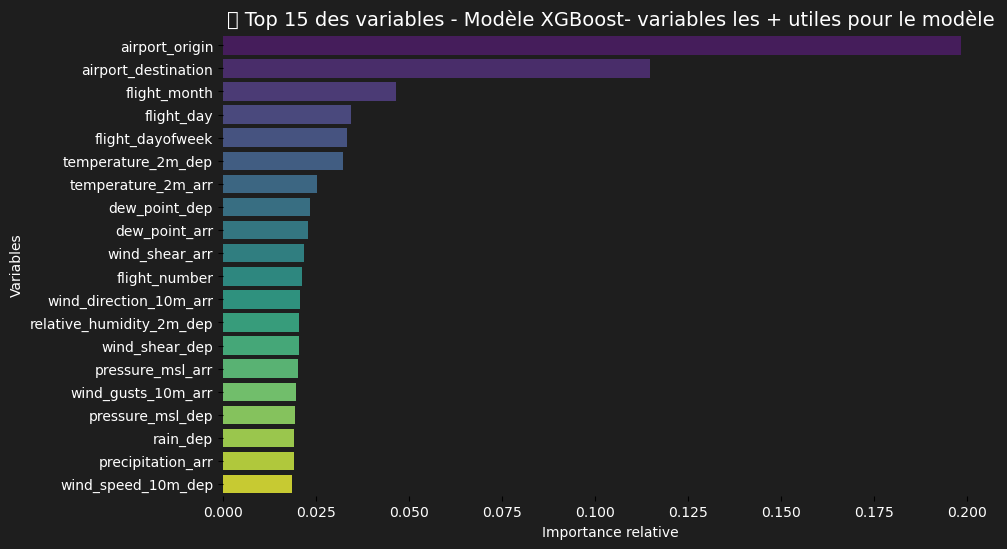

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
# 1. On récupère les importances
importances = xgb_model.feature_importances_

#  récupère les noms des colonnes directement utilisés par le modèle
labels = xgb_model.get_booster().feature_names
# Si jamais le modèle n'a pas enregistré les noms, on utilise X_train
if labels is None:
    labels = X_train.columns 
if len(labels) != len(importances):
    print(f"⚠️ Erreur de taille : Labels ({len(labels)}) vs Importances ({len(importances)})")
    min_len = min(len(labels), len(importances))
    feature_df = pd.DataFrame({'Feature': labels[:min_len], 'Importance': importances[:min_len]})
else:
    feature_df = pd.DataFrame({'Feature': labels, 'Importance': importances})

feature_df = feature_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 6), facecolor='#1E1E1E')
ax = sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')

ax.set_facecolor('#1E1E1E')
ax.set_title(f'🚀 Top 15 des variables - Modèle {TYPE_MODEL}- variables les + utiles pour le modèle', color='white', fontsize=14)
ax.set_xlabel('Importance relative', color='white')
ax.set_ylabel('Variables', color='white')
plt.xticks(color='white')
plt.yticks(color='white')
sns.despine(left=True, bottom=True)

plt.show()

Colonnes datetime problématiques droppées : []


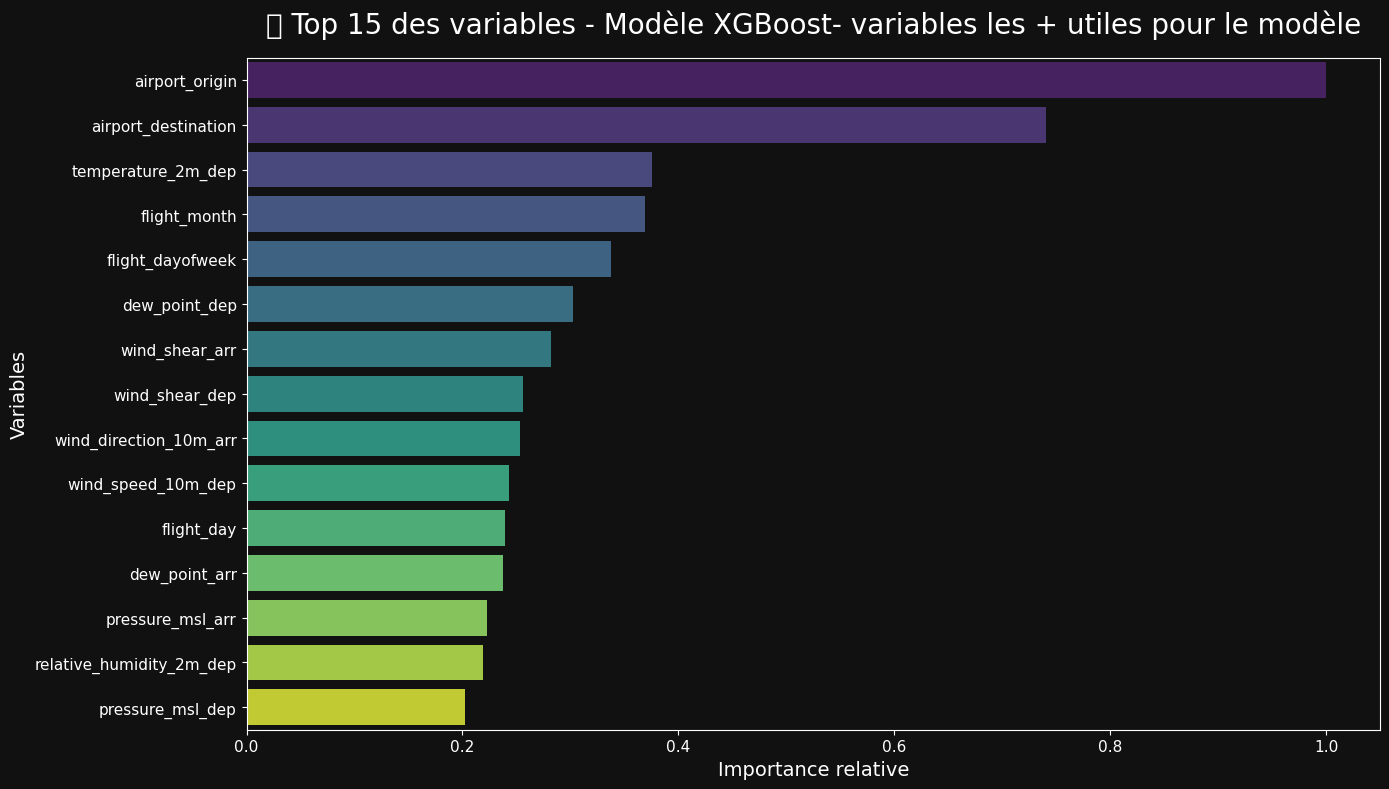

,Feature,SHAP_Importance,Correlation,SHAP_norm,Corr_norm,Importance_relative
1,airport_origin,0.540969,0.257154,1.000000,1.000000,1.000000
2,airport_destination,0.408429,0.181867,0.754995,0.707233,0.740666
19,temperature_2m_dep,0.146518,0.159634,0.270844,0.620772,0.375822
39,flight_month,0.258076,0.030143,0.477062,0.117219,0.369109
41,flight_dayofweek,0.217271,0.048458,0.401634,0.188439,0.337675
4,dew_point_dep,0.133234,0.111445,0.246288,0.433380,0.302416
29,wind_shear_arr,0.159298,0.064760,0.294467,0.251835,0.281678
11,wind_shear_dep,0.138577,0.066211,0.256165,0.257475,0.256558
32,wind_direction_10m_arr,0.147570,0.053116,0.272788,0.206553,0.252918
13,wind_speed_10m_dep,0.130684,0.063377,0.241575,0.246456,0.243039


🧬 SHAP SUMMARY PLOT


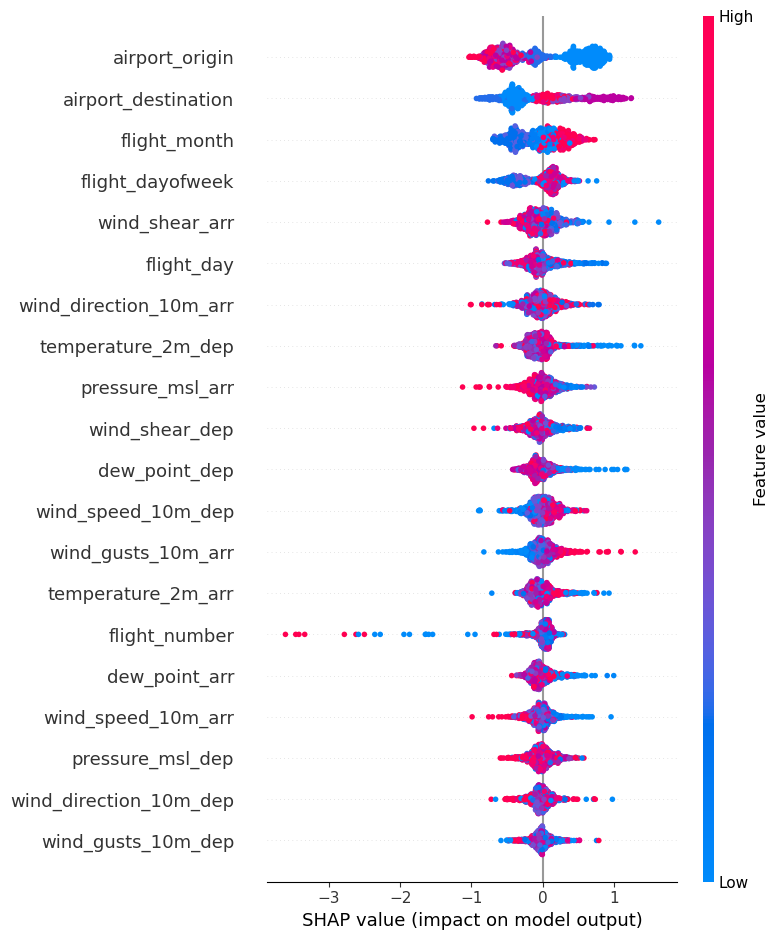

In [39]:
# =========================================================
# 41. SHAP + CORRÉLATION LINÉAIRE + GRAPHIQUE FINAL
# =========================================================

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Reconstituer une base propre utilisée pour l'interprétation
# -----------------------------
X_interpret = df_train_final.drop(columns=cols_a_virer + ['retard_arrivee'], errors='ignore').copy()
X_interpret = datetime_clean(X_interpret, datetime_cols)

# garder les mêmes colonnes catégorielles que pendant l'entraînement
cat_cols_interpret = X_interpret.select_dtypes(include=["object", "category"]).columns.tolist()

# encoder avec le MEME encoder déjà fit plus haut
if len(cat_cols_interpret) > 0:
    X_interpret[cat_cols_interpret] = encoder.transform(X_interpret[cat_cols_interpret].astype(str))

# imputation simple comme plus haut
num_cols_interpret = X_interpret.select_dtypes(include=np.number).columns.tolist()
X_interpret[num_cols_interpret] = X_interpret[num_cols_interpret].fillna(X_interpret[num_cols_interpret].median())

# réalignement de sécurité sur les colonnes du modèle
if hasattr(best_model, "feature_names_in_"):
    train_feature_order = list(best_model.feature_names_in_)
else:
    train_feature_order = list(X_train.columns)

for col in train_feature_order:
    if col not in X_interpret.columns:
        X_interpret[col] = 0

X_interpret = X_interpret[train_feature_order]

# -----------------------------
# SHAP
# -----------------------------
sample_size = min(1000, len(X_interpret))
X_shap_sample = X_interpret.sample(sample_size, random_state=42)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap_sample)

# gestion binaire / multiclass selon sortie shap
if isinstance(shap_values, list):
    shap_array = shap_values[1] if len(shap_values) > 1 else shap_values[0]
else:
    shap_array = shap_values

shap_importance = np.abs(shap_array).mean(axis=0)

df_shap = pd.DataFrame({
    "Feature": X_shap_sample.columns,
    "SHAP_Importance": shap_importance
})

# -----------------------------
# Corrélation linéaire absolue avec la target
# -----------------------------
y_corr = df_train_final.loc[X_interpret.index, 'retard_arrivee'].astype(int)

corr_values = []
for col in X_interpret.columns:
    try:
        corr = np.corrcoef(X_interpret[col].astype(float), y_corr)[0, 1]
        if np.isnan(corr):
            corr = 0
    except Exception:
        corr = 0
    corr_values.append(abs(corr))

df_corr = pd.DataFrame({
    "Feature": X_interpret.columns,
    "Correlation": corr_values
})

# -----------------------------
# Fusion SHAP + Corrélation
# pondération : SHAP 70% / Corrélation 30%
# -----------------------------
df_importance = df_shap.merge(df_corr, on="Feature", how="inner")

df_importance["SHAP_norm"] = df_importance["SHAP_Importance"] / df_importance["SHAP_Importance"].max()
df_importance["Corr_norm"] = df_importance["Correlation"] / df_importance["Correlation"].max()

df_importance["Importance_relative"] = (
    0.7 * df_importance["SHAP_norm"] +
    0.3 * df_importance["Corr_norm"]
)

df_importance = df_importance.sort_values(by="Importance_relative", ascending=False)

# -----------------------------
# Top 15 graphique style sombre
# -----------------------------
top_n = 15
df_top = df_importance.head(top_n).copy()

plt.figure(figsize=(14, 8), facecolor="#111111")
ax = sns.barplot(
    data=df_top,
    x="Importance_relative",
    y="Feature",
    palette="viridis"
)

ax.set_facecolor("#111111")
plt.gcf().patch.set_facecolor("#111111")

ax.set_title(
    f"🚀 Top {top_n} des variables - Modèle {TYPE_MODEL}- variables les + utiles pour le modèle",
    color="white",
    fontsize=20,
    pad=18
)
ax.set_xlabel("Importance relative", color="white", fontsize=14)
ax.set_ylabel("Variables", color="white", fontsize=14)

ax.tick_params(axis='x', colors='white', labelsize=11)
ax.tick_params(axis='y', colors='white', labelsize=11)

for spine in ax.spines.values():
    spine.set_color("white")

plt.tight_layout()
plt.show()

# -----------------------------
# Tableau détail
# -----------------------------
display(df_importance.head(20))

# -----------------------------
# SHAP summary plot
# -----------------------------
print("🧬 SHAP SUMMARY PLOT")
shap.summary_plot(shap_array, X_shap_sample)